In [64]:
import sys
sys.path.append("..")
%run "../moduli.py"

Funzione Teorica
$$A(\omega) = \frac{1}{\sqrt{ (1 - \frac{\omega^2}{\Omega^2})^2 + \frac{1}{Q^2}\frac{\omega^2}{\Omega^2}}}$$

con $ \omega = 2 \pi f$.

In [65]:
def modello(par, f):  # f in Hz
    Omega, Q, area, x_off, y_off = par
    omega = 2 * np.pi * (f + x_off)
    return area / np.sqrt(
        (1 - (omega**2 / Omega**2))**2 +
        (1 / Q**2) * (omega**2 / Omega**2)
    ) + y_off

param_labels = ["\\Omega", "Q", "Area", "f_{off}", "A_{off}"]

beta0 = [2*np.pi*70000, 3, 1, 1, 1]

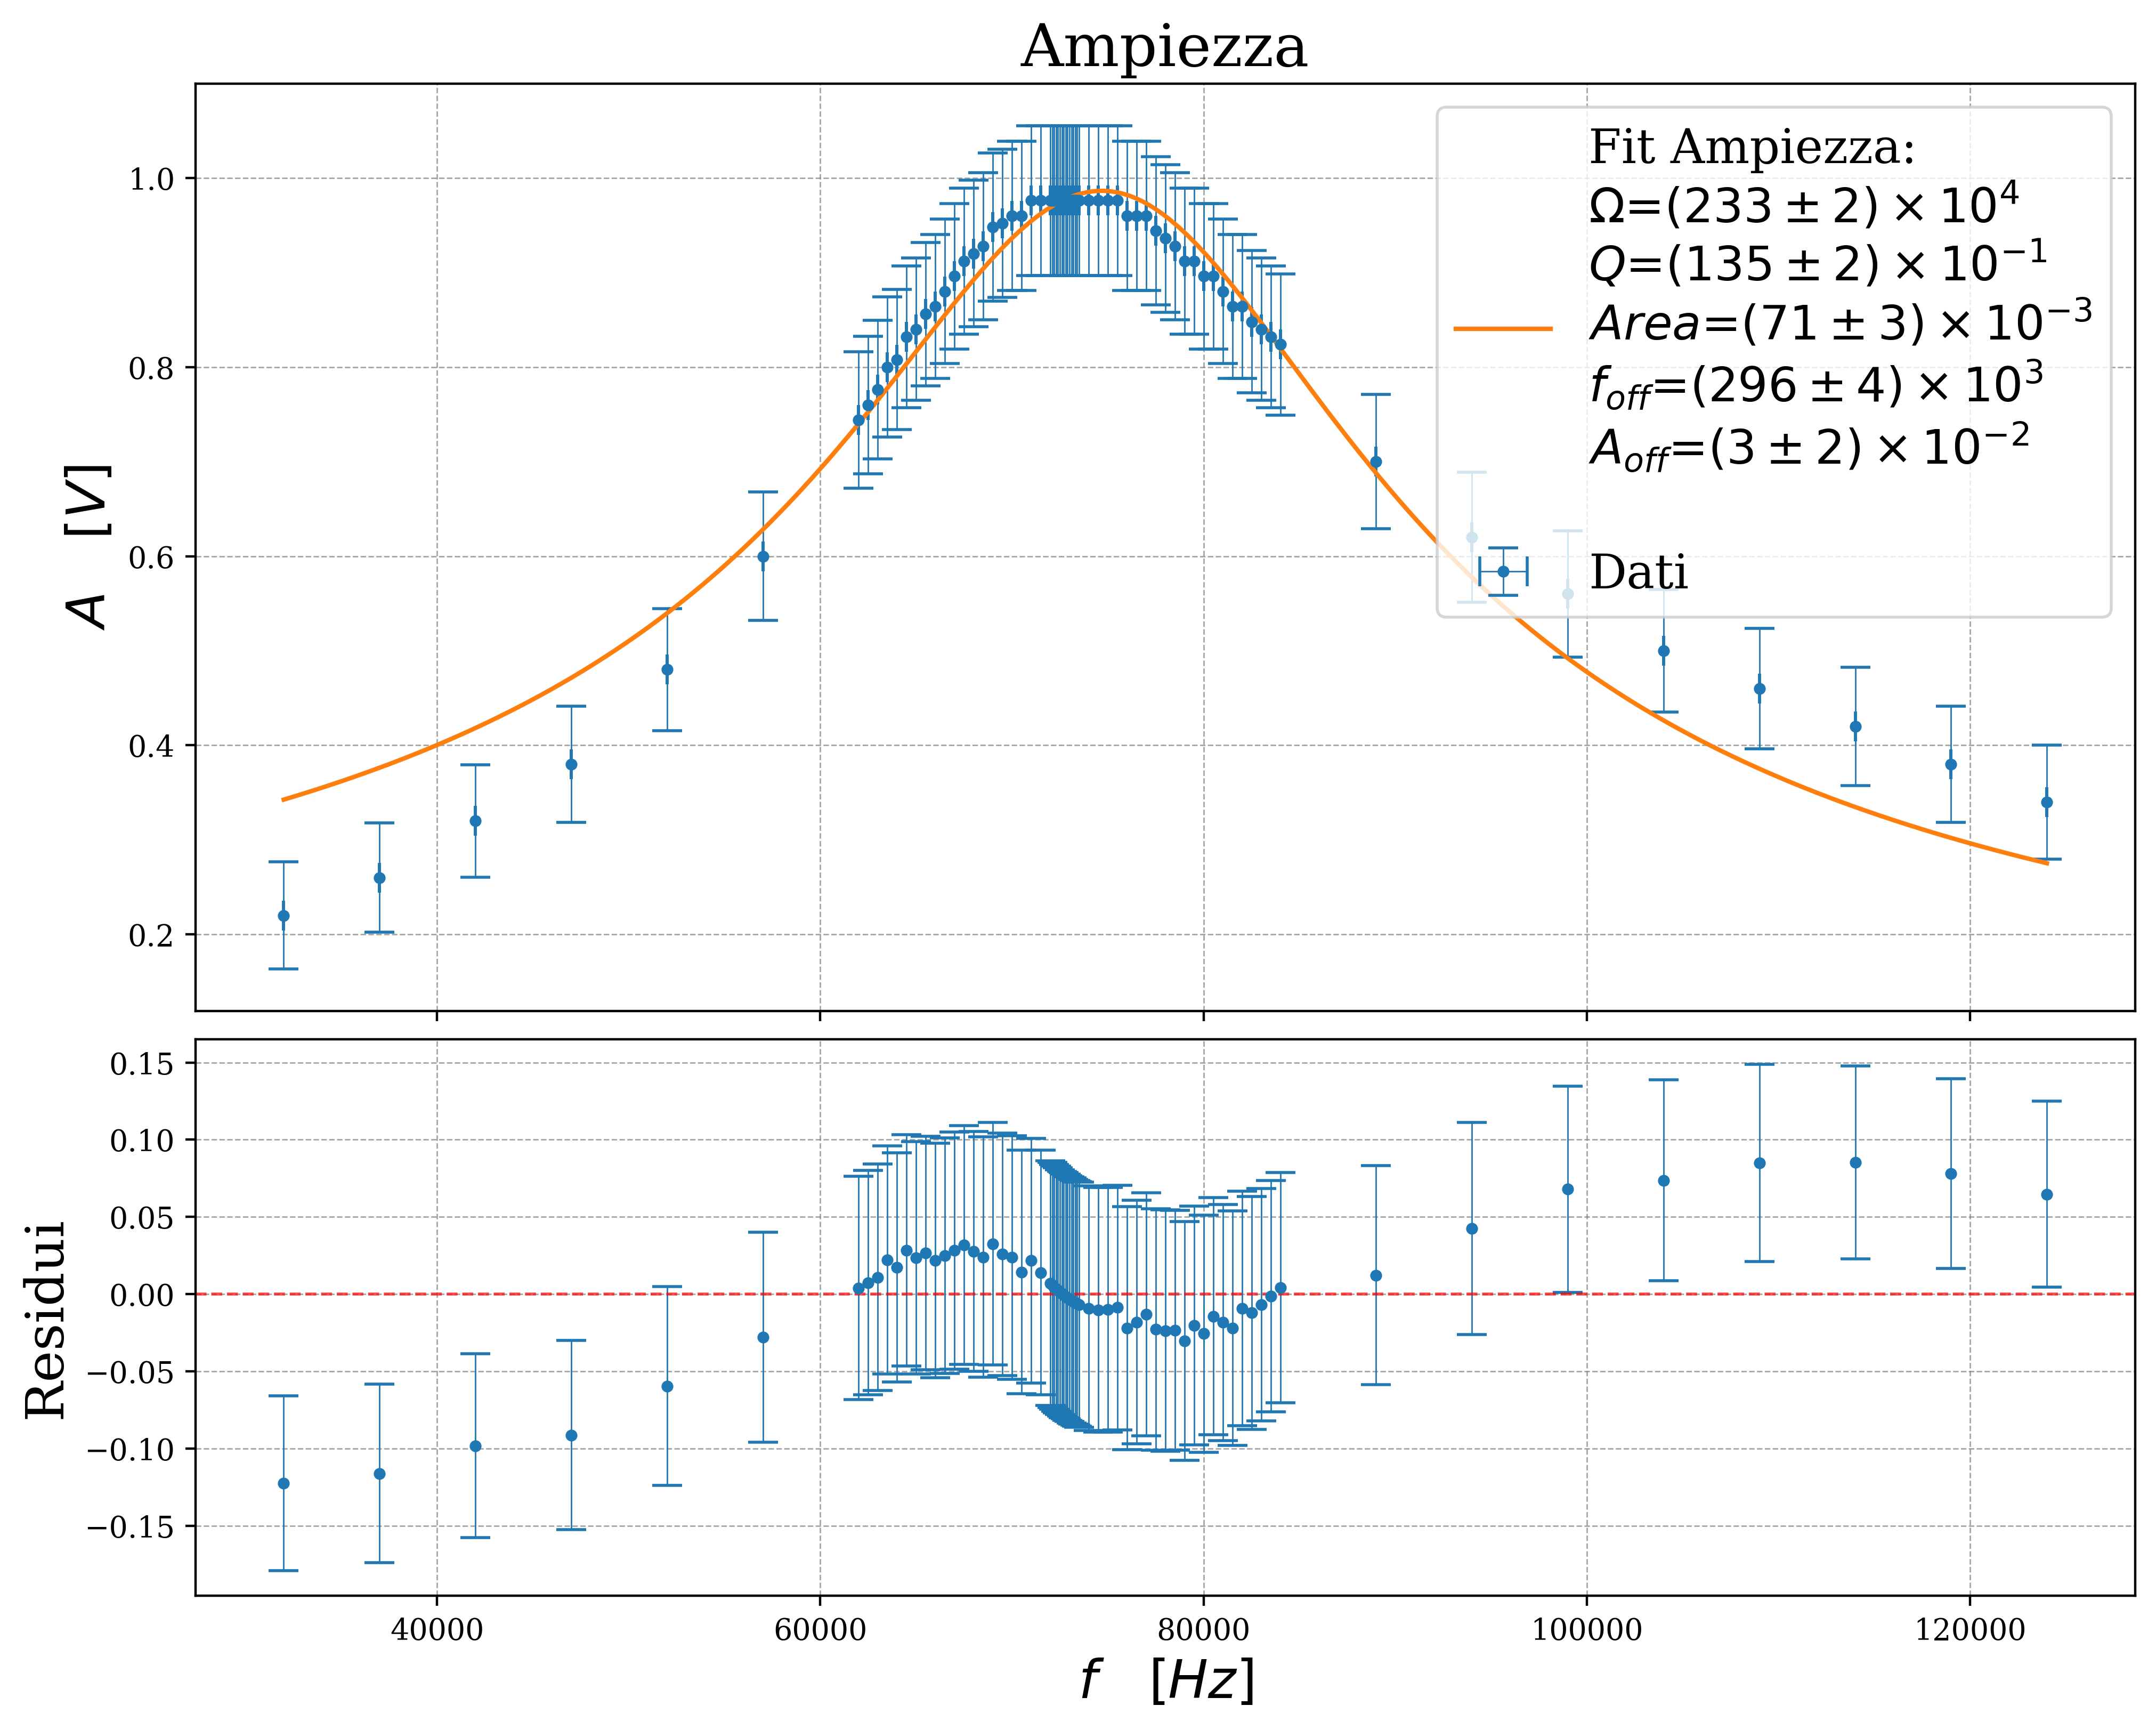

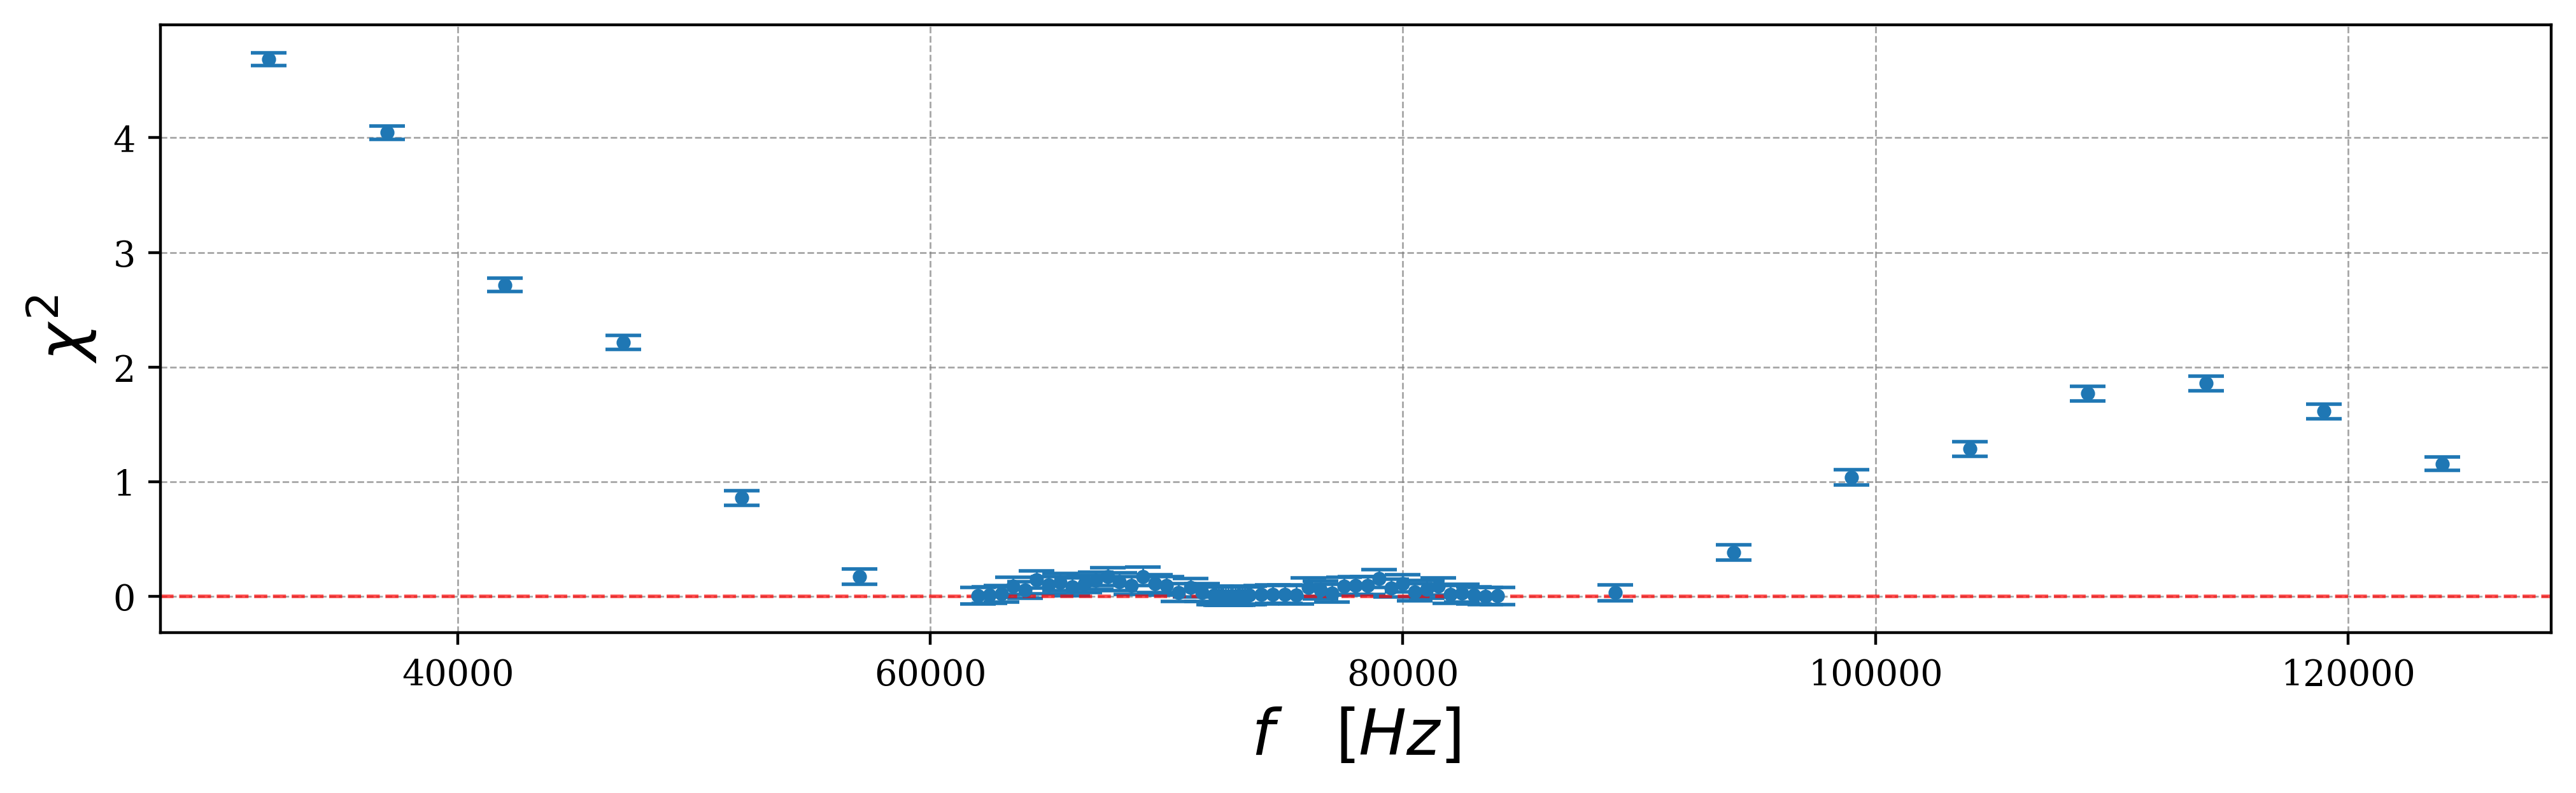

In [66]:
analisi = analizza("ampiezza.json", modello, param_labels, beta0 )

In [67]:
print(analisi)

Parametri regressione :
2334750.656198841 ± 21904.682650268238
13.493310575335574 ± 0.2052916839577754
0.07053932183557002 ± 0.002534777079649503
296392.7435938296 ± 3522.588523759701
0.033897215180864984 ± 0.02155822783711011

Somma residui :
0.0937
Somma chi quadri e chi ridotto :
26.6789
0.4042



In [68]:
par = analisi.anal[0]
spar = analisi.anal[1]

# Pickle per profilazione: solo i primi 2 parametri (Omega, Q)
parametri_profilazione = [[par[0], par[1]], [spar[0], spar[1]]]
print("Parametri per profilazione:", parametri_profilazione)
let.esporta_pickle(parametri_profilazione, "ampiezza.pkl")

# Parametri fissi: area, x_off, y_off
parametri_fissi = {
    "area": par[2], "s_area": spar[2],
    "x_off": par[3], "s_x_off": spar[3],
    "y_off": par[4], "s_y_off": spar[4]
}
import json
with open("ampiezza_params_fissi.json", "w") as f:
    json.dump(parametri_fissi, f, indent=2)
print("Parametri fissi salvati:", parametri_fissi)

Parametri per profilazione: [[np.float64(2334750.656198841), np.float64(13.493310575335574)], [np.float64(21904.682650268238), np.float64(0.2052916839577754)]]
Parametri fissi salvati: {'area': np.float64(0.07053932183557002), 's_area': np.float64(0.002534777079649503), 'x_off': np.float64(296392.7435938296), 's_x_off': np.float64(3522.588523759701), 'y_off': np.float64(0.033897215180864984), 's_y_off': np.float64(0.02155822783711011)}
